In [2]:

import os
import sys
import json
import pickle
import datetime
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from dotenv import load_dotenv

load_dotenv()

#LangChain Stuff
from langchain.document_loaders import PyMuPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.vectorstores import Chroma
# from langchain.embeddings import OpenAIEmbeddings
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain.chains import RetrievalQA

# LangChain Model Wrappers
from langchain.chat_models import ChatOpenAI
from langchain.chat_models import ChatAnthropic
from langchain.llms.replicate import Replicate

from typing import List, Tuple, Union, Optional, Callable

In [7]:

results = pd.read_csv("results/gemini-2.5-flash-lite_inContext.csv")
results.head()

,Unnamed: 0,provider,model_name,eval_mode,temp,max_tokens,financebench_id,question,gold_answer,model_answer,retrieved_documents
0,0,google,gemini-2.5-flash-lite,inContext,0.01,2048,financebench_id_03029,What is the FY2018 capital expenditure amount ...,$1577.00,The FY2018 capital expenditure amount for 3M w...,[]
1,1,google,gemini-2.5-flash-lite,inContext,0.01,2048,financebench_id_04672,Assume that you are a public equities analyst....,$8.70,Here's how to determine 3M's year-end FY2018 n...,[]
2,2,google,gemini-2.5-flash-lite,inContext,0.01,2048,financebench_id_00499,Is 3M a capital-intensive business based on FY...,"No, the company is managing its CAPEX and Fixe...","Yes, 3M can be considered a capital-intensive ...",[]
3,3,google,gemini-2.5-flash-lite,inContext,0.01,2048,financebench_id_01226,What drove operating margin change as of FY202...,Operating Margin for 3M in FY2022 has decrease...,The operating margin for 3M decreased from 20....,[]
4,4,google,gemini-2.5-flash-lite,inContext,0.01,2048,financebench_id_01865,"If we exclude the impact of M&A, which segment...",The consumer segment shrunk by 0.9% organically.,"Based on the provided filing, the **Consumer**...",[]


In [9]:
from google import genai

client = genai.Client()

response = client.models.generate_content(
    model="gemini-2.5-flash-lite",
    contents="Explain how AI works in a few words",
)

print(response.text)

Learning from data to make predictions or decisions.


In [11]:
import pandas as pd
from tqdm import tqdm
from google import genai
import time

# Assuming the client is already set up as in the provided code
client = genai.Client()

# Load the results CSV
df = pd.read_csv("results/gemini-2.5-flash-lite_inContext.csv")

# Assume the columns are named 'gold_answer' and 'model_answer'.
# If they are different, replace with the actual column names from your CSV.
gold_col = 'gold_answer'  # Replace if necessary
model_col = 'model_answer'  # Replace if necessary

# Define the evaluation prompt template
prompt_template = """
You are an expert evaluator for financial question-answering tasks. Your job is to compare a model's answer to a gold standard answer and classify the model's response into exactly one of the following three categories:

1. Correct Answer: This is the desired behavior. The model's answer is correct if it matches the gold standard answer, allowing for minor deviations such as differences in units (e.g., billions vs. millions if convertible), very small rounding errors, or rephrasing that preserves the meaning. If the model provides the right final answer with supporting logic that is consistent with the gold standard, it is correct.

2. Incorrect Answer: The model's answer is incorrect if it deviates significantly from the gold standard, including calculations off by notable margins, made-up information, wrong direction of effects (e.g., positive vs. negative growth), or providing the right final answer but with logic or calculations that explicitly contradict the evidence in the gold standard answer.

3. Refusal: The model explicitly states that it cannot answer the question because it does not have access to the right information, real-time data, or similar reasons (e.g., "As an AI, I don’t have real-time data access capabilities...").

Important: 
- Base your judgment solely on the provided definitions.
- If the model's response attempts to answer but is wrong, it is Incorrect, not Refusal.
- Output your response as a JSON object in the following format: {{"category": "Correct Answer" or "Incorrect Answer" or "Refusal", "reason": "A brief explanation of your classification."}}
- Do not output anything else.

Gold standard answer:
{gold_answer}

Model's answer:
{model_answer}
"""

# Function to evaluate a single pair
def evaluate_answer(gold, model):
    prompt = prompt_template.format(gold_answer=gold, model_answer=model)
    response = client.models.generate_content(
        model="gemini-2.5-flash-lite",  
        contents=prompt,
    )
    try:
        # Parse the JSON response
        result = json.loads(response.text.strip())
        return result['category'], result['reason']
    except Exception as e:
        print(f"Error parsing response: {e}")
        print(f"Raw response: {response.text}")
        return "Error", "Parsing failed"

# Add new columns for labels and reasons
df['label'] = ""
df['reason'] = ""

# Evaluate each row
for idx in tqdm(range(len(df)), desc="Evaluating answers"):
    gold = df.at[idx, gold_col]
    model = df.at[idx, model_col]
    category, reason = evaluate_answer(gold, model)
    df.at[idx, 'label'] = category
    df.at[idx, 'reason'] = reason
    time.sleep(5)

# Save the updated DataFrame
df.to_csv("results/gemini-2.5-flash-lite_inContext_evaluated.csv", index=False)

print("Evaluation complete. Results saved to 'results/gemini-2.5-flash-lite_inContext_evaluated.csv'.")

Evaluating answers:  52%|█████▏    | 26/50 [02:29<02:14,  5.60s/it]

Error parsing response: Expecting value: line 1 column 1 (char 0)
Raw response: ```json
{
 "category": "Correct Answer",
 "reason": "The model correctly identifies Amcor's primary industry as packaging, which aligns with the gold standard's description of Amcor as a global leader in packaging production."
}
```


Evaluating answers:  74%|███████▍  | 37/50 [03:34<01:15,  5.81s/it]

Error parsing response: Expecting value: line 1 column 1 (char 0)
Raw response: ```json
{"category": "Correct Answer", "reason": "The model correctly identifies the 'Data Center' segment as having the largest proportional increase in sales by calculating the percentage change for each segment and comparing them."}
```


Evaluating answers: 100%|██████████| 50/50 [04:49<00:00,  5.78s/it]

Evaluation complete. Results saved to 'results/gemini-2.5-flash-lite_inContext_evaluated.csv'.


Model Accuracy (Proportion of Correct Answers): 68.00%


/tmp/ipykernel_128045/786339285.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(x='Category', y='Proportion', data=plot_data, palette='muted')


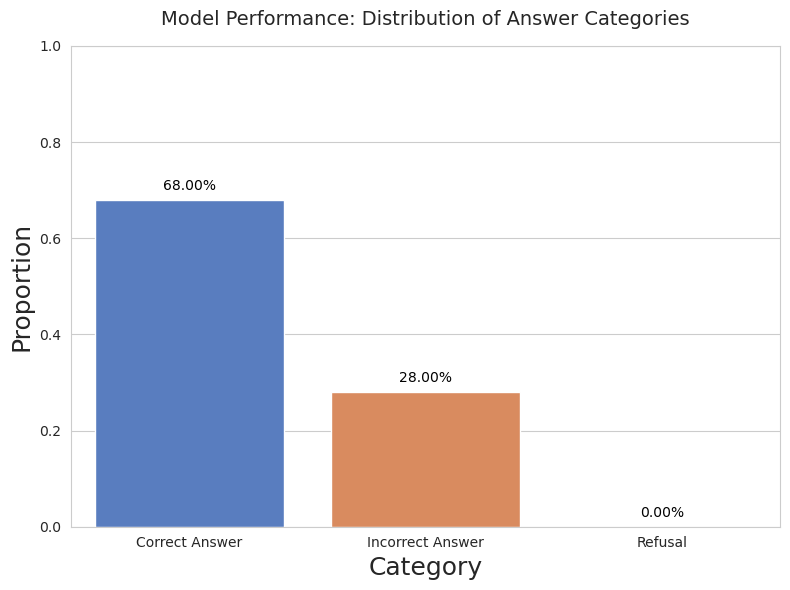

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the evaluated results
df = pd.read_csv("results/gemini-2.5-flash-lite_inContext_evaluated.csv")

# Calculate the counts and proportions for each category
label_counts = df['label'].value_counts()
total = len(df)
proportions = label_counts / total

# Ensure all categories are included, including Refusal with 0 proportion if absent
categories = ['Correct Answer', 'Incorrect Answer', 'Refusal']
proportions_dict = {cat: proportions.get(cat, 0) for cat in categories}

# Create a DataFrame for plotting
plot_data = pd.DataFrame({
    'Category': categories,
    'Proportion': [proportions_dict[cat] for cat in categories]
})

# Calculate accuracy (proportion of Correct Answer)
accuracy = proportions_dict['Correct Answer']
print(f"Model Accuracy (Proportion of Correct Answers): {accuracy:.2%}")

# Set Seaborn style
sns.set_style("whitegrid")

# Create a bar plot
plt.figure(figsize=(8, 6))
bar_plot = sns.barplot(x='Category', y='Proportion', data=plot_data, palette='muted')

# Customize the plot
plt.title('Model Performance: Distribution of Answer Categories', fontsize=14, pad=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.ylim(0, 1)  # Set y-axis to range from 0 to 1 for proportions

# Add proportion labels on top of bars
for p in bar_plot.patches:
    height = p.get_height()
    bar_plot.annotate(f'{height:.2%}', 
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                     textcoords='offset points')

# Show the plot
plt.tight_layout()
plt.show()

Model Accuracy (Proportion of Correct Answers): 70.83%


/tmp/ipykernel_128045/3051312661.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(x='Category', y='Proportion', data=plot_data, palette=palette)


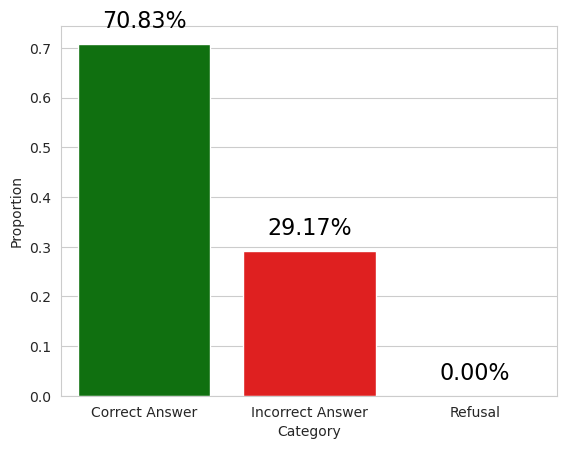

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the evaluated results
df = pd.read_csv("results/gemini-2.5-flash-lite_inContext_evaluated.csv")

# Calculate the counts and proportions for each category
label_counts = df['label'].value_counts()
mask = df['label'] != "Error"
total = len(df[mask])
proportions = label_counts / total

# Ensure all categories are included, including Refusal with 0 proportion if absent
categories = ['Correct Answer', 'Incorrect Answer', 'Refusal']
proportions_dict = {cat: proportions.get(cat, 0) for cat in categories}

# Create a DataFrame for plotting
plot_data = pd.DataFrame({
    'Category': categories,
    'Proportion': [proportions_dict[cat] for cat in categories]
})

# Calculate accuracy (proportion of Correct Answer)
accuracy = proportions_dict['Correct Answer']
print(f"Model Accuracy (Proportion of Correct Answers): {accuracy:.2%}")

# Define custom colors: green for Correct, red for Incorrect, gray for Refusal
palette = {'Correct Answer': 'green', 'Incorrect Answer': 'red', 'Refusal': 'gray'}

# Create a Seaborn bar plot with custom colors
bar_plot = sns.barplot(x='Category', y='Proportion', data=plot_data, palette=palette)

# Add proportion labels on top of bars with larger font size
for p in bar_plot.patches:
    height = p.get_height()
    bar_plot.annotate(f'{height:.2%}',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=16, color='black', xytext=(0, 8),
                     textcoords='offset points')

# Show the plot
plt.show()